# Huấn luyện Stable-Baselines3 DQN trên Atari Pong

Sổ tay này hướng dẫn huấn luyện mô hình **DQN** sử dụng thư viện **Stable-Baselines3 (SB3)** tích hợp đầy đủ các tiêu chuẩn kỹ thuật chất lượng cao.

## Giới thiệu về thư viện Stable-Baselines3 và DQN

### 1. Thư viện Stable-Baselines3
Stable-Baselines3 (SB3) là một tập hợp các triển khai chất lượng cao của các thuật toán Học tăng cường bằng PyTorch. Nó kế thừa triết lý thiết kế thân thiện của Stable-Baselines gốc, được chuẩn hóa chặt chẽ và tối ưu hóa hiệu năng cực tốt cho cộng đồng nghiên cứu và ứng dụng.

### 2. Thuật toán DQN trong SB3
Cài đặt thuật toán DQN của SB3 là phiên bản chuẩn hóa hiệu năng cao. Nó đi kèm cấu hình mặc định tuyệt vời như Nature CNN, bộ đệm trải nghiệm hiệu quả cao, suy giảm tham số thăm dò epsilon tối ưu và các công cụ giám sát tiện lợi.

## Cấu hình môi trường và Import các thư viện

Để chạy notebook này độc lập trong thư mục con `notebooks/`, chúng ta cần thêm thư mục gốc của dự án vào đường dẫn tìm kiếm `sys.path` để import chính xác các module từ `src/`.

In [ ]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Thêm thư mục gốc vào đường dẫn hệ thống để import src
sys.path.append(os.path.abspath(os.path.join('..')))

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

from src.common.wrappers import make_atari_env
from src.common.utils import CSVLogger

## Kiểm tra tăng tốc phần cứng (GPU CUDA)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị huấn luyện: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")

## Định nghĩa Siêu tham số (Hyperparameters)

Cấu hình các siêu tham số huấn luyện trực tiếp ngay trong notebook:

In [ ]:
env_id = "PongNoFrameskip-v4"
total_timesteps = 500000   # Tổng số bước môi trường huấn luyện
lr = 1e-4                  # Tốc độ học
buffer_size = 30000       # Kích thước tối đa bộ đệm Replay
batch_size = 32            # Cỡ mẫu cập nhật
learning_starts = 5000    # Các bước khởi động
target_update_interval = 2000 # Đồng bộ target network
train_freq = 4             # Tần suất cập nhật (mỗi 4 steps)
seed = 42                  # Seed

save_dir = "../data/models"
log_dir = "../data/logs"

os.makedirs(save_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

## Định nghĩa Custom Callback cho Logging và Checkpoint

Định nghĩa `SB3CSVLoggerCallback` kế thừa `BaseCallback` của SB3 để tự động:
1. Ghi nhận số liệu (`reward`, `length`, `steps`) của mỗi tập phim vào CSV.
2. Lưu checkpoint định kỳ mỗi 100,000 steps vào thư mục `data/models/`.

In [ ]:
class SB3CSVLoggerCallback(BaseCallback):
    def __init__(self, csv_filepath: str, save_dir: str, algo_name: str, verbose: int = 0):
        super().__init__(verbose)
        self.csv_filepath = csv_filepath
        self.save_dir = save_dir
        self.algo_name = algo_name
        self.episode_count = 0
        self.last_checkpoint_step = 0
        self.csv_logger = None
        self.recent_rewards = []
        
    def _on_training_start(self) -> None:
        headers = ["episode", "reward", "steps", "length"]
        self.csv_logger = CSVLogger(self.csv_filepath, headers)
        self.episode_count = 0
        self.last_checkpoint_step = 0
        
    def _on_step(self) -> bool:
        # 1. Lưu checkpoint định kỳ mỗi 100,000 steps
        current_step = self.num_timesteps
        if current_step - self.last_checkpoint_step >= 100000:
            self.last_checkpoint_step = (current_step // 100000) * 100000
            save_path = os.path.join(self.save_dir, f"{self.algo_name}_sb3_step_{self.last_checkpoint_step}.zip")
            self.model.save(save_path)
            print(f"Đã lưu checkpoint định kỳ: {save_path} tại bước {self.last_checkpoint_step}")
            
        # 2. Ghi nhận thông số khi kết thúc tập phim
        infos = self.locals.get("infos")
        if infos is not None:
            for info in infos:
                if "episode" in info:
                    self.episode_count += 1
                    ep_reward = info["episode"]["r"]
                    self.recent_rewards.append(ep_reward)
                    if len(self.recent_rewards) > 10:
                        self.recent_rewards.pop(0)
                    
                    self.csv_logger.log({
                        "episode": self.episode_count,
                        "reward": ep_reward,
                        "steps": self.num_timesteps,
                        "length": info["episode"]["l"]
                    })
                    
                    # Dừng sớm nếu điểm trung bình 10 tập gần nhất >= 18.0
                    if len(self.recent_rewards) >= 10 and np.mean(self.recent_rewards) >= 18.0:
                        print(f"Dừng sớm (Early Stopping)! Điểm trung bình 10 tập gần nhất: {np.mean(self.recent_rewards):.1f} >= 18.0. Đã giải quyết thành công Pong!")
                        return False
        return True

## Khởi tạo Môi trường và Đối tượng Mô hình SB3 DQN

In [ ]:
env = make_atari_env(env_id)
env = Monitor(env) # Cần wrapper Monitor để ghi nhận thống kê tập phim cho callback của SB3
env.action_space.seed(seed)

# model = DQN(
#     policy="CnnPolicy",
#     env=env,
#     learning_rate=lr,
#     buffer_size=buffer_size,
#     learning_starts=learning_starts,
#     batch_size=batch_size,
#     target_update_interval=target_update_interval,
#     train_freq=train_freq,
#     exploration_fraction=0.1,
#     exploration_final_eps=0.01,
#     exploration_initial_eps=1.0,
#     seed=seed,
#     device=device,
#     tensorboard_log=os.path.join(log_dir, "tb"),
#     policy_kwargs=dict(normalize_images=False),
#     optimize_memory_usage=True,
#     verbose=1
# )

model = DQN(
    policy="CnnPolicy",
    env=env,
    learning_rate=lr,
    buffer_size=buffer_size,
    learning_starts=learning_starts,
    batch_size=batch_size,
    target_update_interval=target_update_interval,
    train_freq=train_freq,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    exploration_initial_eps=1.0,
    seed=seed,
    device=device,
    tensorboard_log=os.path.join(log_dir, "tb"),
    policy_kwargs=dict(normalize_images=False),
    optimize_memory_usage=True,  # Kích hoạt tối ưu giảm 50% RAM hệ thống
    replay_buffer_kwargs=dict(handle_timeout_termination=False),  # Tắt xử lý timeout để tương thích
    verbose=1
)

## Kích hoạt Huấn luyện Mô hình

In [12]:
csv_filepath = os.path.join(log_dir, f"dqn_sb3.csv")
callback = SB3CSVLoggerCallback(
    csv_filepath=csv_filepath,
    save_dir=save_dir,
    algo_name="dqn"
)

print("Bắt đầu huấn luyện Stable-Baselines3 DQN...")
model.learn(total_timesteps=total_timesteps, callback=callback)

# Lưu mô hình cuối cùng
final_save_path = os.path.join(save_dir, "dqn_sb3_final.zip")
model.save(final_save_path)
print(f"Đã lưu mô hình cuối cùng tại: {final_save_path}")

env.close()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 977      |
|    ep_rew_mean      | -20      |
|    exploration_rate | 0.923    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1153     |
|    time_elapsed     | 3        |
|    total_timesteps  | 3908     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 899      |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.858    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 726      |
|    time_elapsed     | 9        |
|    total_timesteps  | 7193     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0148   |
|    n_updates        | 548      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

## Vẽ đồ thị kết quả học tập

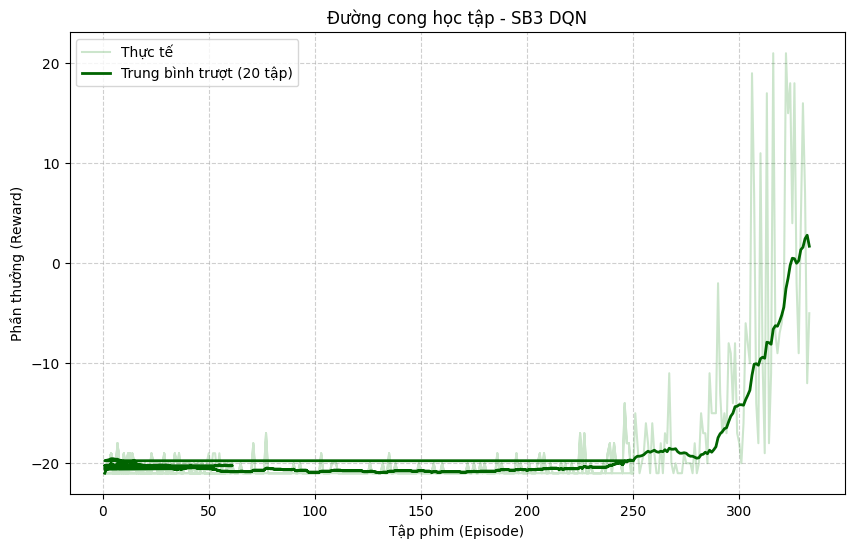

In [13]:
try:
    df = pd.read_csv(csv_filepath)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df["episode"], df["reward"], alpha=0.2, color="green", label="Thực tế")
    rolling_rew = df["reward"].rolling(window=20, min_periods=1).mean()
    plt.plot(df["episode"], rolling_rew, color="darkgreen", linewidth=2, label="Trung bình trượt (20 tập)")
    plt.title("Đường cong học tập - SB3 DQN")
    plt.xlabel("Tập phim (Episode)")
    plt.ylabel("Phần thưởng (Reward)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
except Exception as e:
    print(f"Không thể vẽ đồ thị: {e}")